<div style="text-align: center;">
    <h1>Exploratory Data Analysis (EDA)</h1>
</div>

#### Importar librerias

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency
from scipy.stats import kendalltau

**Obtener los datos**

In [36]:
try:
    data_org = pd.read_csv("../dataset/cardio_train.csv",sep=";")
except FileNotFoundError:
    print("No se ha encontrado el archivo de datos. Verifique el directorio.")
    exit(1)


<div style="text-align: center;">
    <h2>Descripción de los datos</h2>
</div>

El dataset contiene **70,000 registros de pacientes** y **12 variables en total**:  
**11 variables predictoras** y **1 variable objetivo**.  

Los datos fueron recolectados durante un examen médico y combinan información objetiva del paciente, mediciones clínicas del examen e información subjetiva reportada por el paciente.

### Tipos de variables de entrada

- **Objetivas**: información medible del paciente, como edad, altura, peso y género.
- **De examen**: resultados obtenidos durante el examen médico, como presión arterial, colesterol y glucosa.
- **Subjetivas**: información declarada por el paciente, como hábito de fumar, consumo de alcohol y actividad física.
- **Variable objetivo**: indica si el paciente presenta o no enfermedad cardiovascular.

---

### Variables objetivas

- **`age`**  
  - Tipo: objetiva  
  - Descripción: edad del paciente  
  - Tipo de dato: `int`  
  - Unidad: **días**  

- **`height`**  
  - Tipo: objetiva  
  - Descripción: altura del paciente  
  - Tipo de dato: `int`  
  - Unidad: **centímetros (cm)**

- **`weight`**  
  - Tipo: objetiva  
  - Descripción: peso del paciente  
  - Tipo de dato: `float`  
  - Unidad: **kilogramos (kg)**

- **`gender`**  
  - Tipo: objetiva  
  - Descripción: género del paciente  
  - Tipo de dato: categórica nominal codificada  
  - Valores:
    - `1`: mujer
    - `2`: hombre

---

### Variables de examen médico

- **`ap_hi`**  
  - Tipo: de examen  
  - Descripción: presión arterial sistólica  
  - Tipo de dato: `int`  
  - Unidad: **mmHg**
  - Interpretación: corresponde a la presión máxima ejercida sobre las arterias cuando el corazón se contrae.
  - Nota: en algunos análisis puede renombrarse como `systolic_blood_pressure`.

- **`ap_lo`**  
  - Tipo: de examen  
  - Descripción: presión arterial diastólica  
  - Tipo de dato: `int`  
  - Unidad: **mmHg**
  - Interpretación: corresponde a la presión mínima ejercida sobre las arterias cuando el corazón está en reposo entre latidos.
  - Nota: en algunos análisis puede renombrarse como `diastolic_blood_pressure`.

- **`cholesterol`**  
  - Tipo: de examen  
  - Descripción: nivel de colesterol  
  - Tipo de dato: categórica ordinal codificada  
  - Valores:
    - `1`: normal
    - `2`: por encima de lo normal
    - `3`: muy por encima de lo normal
  - Nota: aunque está codificada con números, no debe tratarse como una variable numérica continua.

- **`gluc`**  
  - Tipo: de examen  
  - Descripción: nivel de glucosa  
  - Tipo de dato: categórica ordinal codificada  
  - Valores:
    - `1`: normal
    - `2`: por encima de lo normal
    - `3`: muy por encima de lo normal
  - Nota: en algunos análisis puede renombrarse como `glucose`.

---

### Variables subjetivas

- **`smoke`**  
  - Tipo: subjetiva  
  - Descripción: hábito de fumar  
  - Tipo de dato: binaria  
  - Valores:
    - `0`: no fuma
    - `1`: fuma

- **`alco`**  
  - Tipo: subjetiva  
  - Descripción: consumo de alcohol  
  - Tipo de dato: binaria  
  - Valores:
    - `0`: no consume alcohol
    - `1`: consume alcohol
  - Nota: en algunos análisis puede renombrarse como `alcohol_intake`.

- **`active`**  
  - Tipo: subjetiva  
  - Descripción: actividad física  
  - Tipo de dato: binaria  
  - Valores:
    - `0`: no realiza actividad física
    - `1`: realiza actividad física
  - Nota: en algunos análisis puede renombrarse como `physical_activity`.

---

### Variable objetivo

- **`cardio`**  
  - Tipo: variable objetivo  
  - Descripción: presencia o ausencia de enfermedad cardiovascular  
  - Tipo de dato: binaria  
  - Valores:
    - `0`: no presenta enfermedad cardiovascular
    - `1`: presenta enfermedad cardiovascular
  - Nota: en algunos análisis puede renombrarse como `cardiovascular_disease`.

---

## Resumen de variables

| Variable original | Nombre descriptivo sugerido | Tipo conceptual | Tipo estadístico | Unidad / valores |
|---|---|---|---|---|
| `age` | `age_days` | Objetiva | Numérica discreta | días |
| `height` | `height_cm` | Objetiva | Numérica continua/discreta | cm |
| `weight` | `weight_kg` | Objetiva | Numérica continua | kg |
| `gender` | `gender` | Objetiva | Categórica nominal | `1`: mujer, `2`: hombre |
| `ap_hi` | `systolic_blood_pressure` | De examen | Numérica continua/discreta | mmHg |
| `ap_lo` | `diastolic_blood_pressure` | De examen | Numérica continua/discreta | mmHg |
| `cholesterol` | `cholesterol` | De examen | Categórica ordinal | `1`, `2`, `3` |
| `gluc` | `glucose` | De examen | Categórica ordinal | `1`, `2`, `3` |
| `smoke` | `smoke` | Subjetiva | Binaria | `0`, `1` |
| `alco` | `alcohol_intake` | Subjetiva | Binaria | `0`, `1` |
| `active` | `physical_activity` | Subjetiva | Binaria | `0`, `1` |
| `cardio` | `cardiovascular_disease` | Objetivo | Binaria | `0`, `1` |

---

#### Primera vista a los datos

In [37]:
data_org.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


Eliminamos la columna id, pues esta no brinda información relevante, adicionalmente **renombramos las columnas para que sean más descriptivas**

In [38]:
data_org = data_org.drop(columns=["id"])

In [39]:
data_org.rename(columns={"ap_hi": "systolic_blood_pressure", "ap_lo":"diastolic_blood_pressure", "gluc": "glucose", "alco": "alcohol_intake", "active": "physical_activity", "cardio": "cardiovascular_disease"}, inplace=True)

La característica de edad (age) está dada en dias, para más comodidad, convertiremos los datos de esta a años

In [40]:
data_edit_age = data_org.copy()
data_edit_age["age"] = np.floor(data_edit_age["age"] / 365 + 0.5).astype(int)
data_edit_age.describe(include="all")

,age,gender,height,weight,systolic_blood_pressure,diastolic_blood_pressure,cholesterol,glucose,smoke,alcohol_intake,physical_activity,cardiovascular_disease
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,53.338686,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,6.765294,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,30.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


**Separación de datos de train, test y validation**

In [41]:
features = data_edit_age.drop(columns=["cardiovascular_disease"])
target = data_edit_age["cardiovascular_disease"]

#separar train del resto
X_train, X_temp, y_train, y_temp = train_test_split(features, target, test_size=0.20, random_state=42, stratify=target)
#separar test del val
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(56000, 11) (7000, 11) (7000, 11)
(56000,) (7000,) (7000,)


In [42]:
# juntar data_train, data_test y data_val para el EDA
data_train = pd.concat([X_train, y_train], axis=1)
data_val = pd.concat([X_val, y_val], axis=1)
data_test = pd.concat([X_test, y_test], axis=1)

Para luego de esto hacer de nueva una pequeña vista a los datos

In [43]:
data_train.info()

<class 'pandas.DataFrame'>
Index: 56000 entries, 58394 to 33894
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       56000 non-null  int64  
 1   gender                    56000 non-null  int64  
 2   height                    56000 non-null  int64  
 3   weight                    56000 non-null  float64
 4   systolic_blood_pressure   56000 non-null  int64  
 5   diastolic_blood_pressure  56000 non-null  int64  
 6   cholesterol               56000 non-null  int64  
 7   glucose                   56000 non-null  int64  
 8   smoke                     56000 non-null  int64  
 9   alcohol_intake            56000 non-null  int64  
 10  physical_activity         56000 non-null  int64  
 11  cardiovascular_disease    56000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 5.6 MB


No hay datos nulos, encontramos variables númericas y categóricas, incluyendo binarias, ordinales y nominales

In [44]:
data_train.describe(include="all")

,age,gender,height,weight,systolic_blood_pressure,diastolic_blood_pressure,cholesterol,glucose,smoke,alcohol_intake,physical_activity,cardiovascular_disease
count,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000
mean,53.333482,1.349107,164.344089,74.222059,129.041732,96.798196,1.366750,1.226679,0.087839,0.053018,0.804946,0.499696
std,6.750139,0.476692,8.226979,14.389746,161.551930,193.567517,0.679918,0.572321,0.283064,0.224071,0.396245,0.500004
min,30.000000,1.000000,57.000000,11.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


Notese que no hay datos **faltantes**, no será necesario usar alguna técnica de imputación

En este análisis se ve necesario relacionar variables como peso y estatura, por esto se creará una variable ordinal de indice de masa corporal (bmi)

In [45]:
# Calcular imc
bmi_value = (data_train["weight"] /(data_train["height"] / 100) ** 2)
# crear columna
data_train["bmi"] = pd.cut(bmi_value, bins=[0, 18.5, 25, 30, 35, 40, np.inf], labels=[0, 1, 2, 3, 4, 5], right=False).astype("Int64")
# 2. Mover columna "bmi" a la posición deseada
col_to_move = "bmi"
target_index =  len(data_train.columns)-2 # El nuevo índice 

# Extraer la columna y eliminarla del original
col = data_train.pop(col_to_move)

# Insertar la columna en la nueva posición
data_train.insert(target_index, col_to_move, col)

Donde:

0: [0, 18.5)   -> underweight

1: [18.5, 25)  -> healthy_weight

2: [25, 30)    -> overweight

3: [30, 35)    -> obesity_class_1

4: [35, 40)    -> obesity_class_2

5: [40, ∞)     -> obesity_class_3

In [46]:
data_train.info()

<class 'pandas.DataFrame'>
Index: 56000 entries, 58394 to 33894
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       56000 non-null  int64  
 1   gender                    56000 non-null  int64  
 2   height                    56000 non-null  int64  
 3   weight                    56000 non-null  float64
 4   systolic_blood_pressure   56000 non-null  int64  
 5   diastolic_blood_pressure  56000 non-null  int64  
 6   cholesterol               56000 non-null  int64  
 7   glucose                   56000 non-null  int64  
 8   smoke                     56000 non-null  int64  
 9   alcohol_intake            56000 non-null  int64  
 10  physical_activity         56000 non-null  int64  
 11  bmi                       56000 non-null  Int64  
 12  cardiovascular_disease    56000 non-null  int64  
dtypes: Int64(1), float64(1), int64(11)
memory usage: 6.0 MB


A continuación dividiremos los datos

In [47]:
def calculate_sets(dataframe):
    categorical = dataframe[["gender", "cholesterol", "glucose", "smoke", "alcohol_intake", "physical_activity","bmi", "cardiovascular_disease"]]
    nominal = categorical[["gender", "smoke", "alcohol_intake", "physical_activity", "cardiovascular_disease"]]
    ordinal = categorical[["cholesterol", "glucose", "bmi"]]
    binary = categorical[["gender","smoke", "alcohol_intake", "physical_activity", "cardiovascular_disease"]]
    numerical = dataframe[["age", "height", "weight", "systolic_blood_pressure", "diastolic_blood_pressure"]]
    return categorical, nominal, ordinal, binary, numerical


In [48]:
categorical, nominal, ordinal, binary, numerical = calculate_sets(data_train)

<div style="text-align: center;">
    <h2>Análisis Univariado y Multivariado</h2>
</div>

Calculamos medidas de tendencia central y de dispersión para categoricas y numericas

Adicional a esto, se calculara el coeficiente de Curtosis y asimetria, para usarla como una herramienta que nos ayudará a detectar mayor probabilidad de encontrar outliers en las distribuciones de los datos

In [49]:
def calculate_metrics(dataframe):
    categorical, nominal, ordinal, binary, numerical = calculate_sets(dataframe)
    cat_col = categorical.columns.to_list()
    num_col = numerical.columns.to_list()

    # medidas de tendencia central y dispersión para las variables numéricas
    mean_num = numerical.mean()
    median_num = numerical.median()
    mode_num = numerical.mode().iloc[0]
    std_num = numerical.std()
    var_num = numerical.var()

    # medidas de tendencia central para las variables categóricas
    mode_cat = categorical.mode().iloc[0]

    #coeficientes de curtosis y asimetría para las variables numéricas
    kurtosis_num = numerical.kurtosis()
    skewness_num = numerical.skew()
    
    return cat_col, num_col, mean_num, median_num, mode_num, std_num, var_num, mode_cat, kurtosis_num, skewness_num

In [50]:
cat_col, num_col, mean_num, median_num, mode_num, std_num, var_num, mode_cat, kurtosis_num, skewness_num = calculate_metrics(data_train)

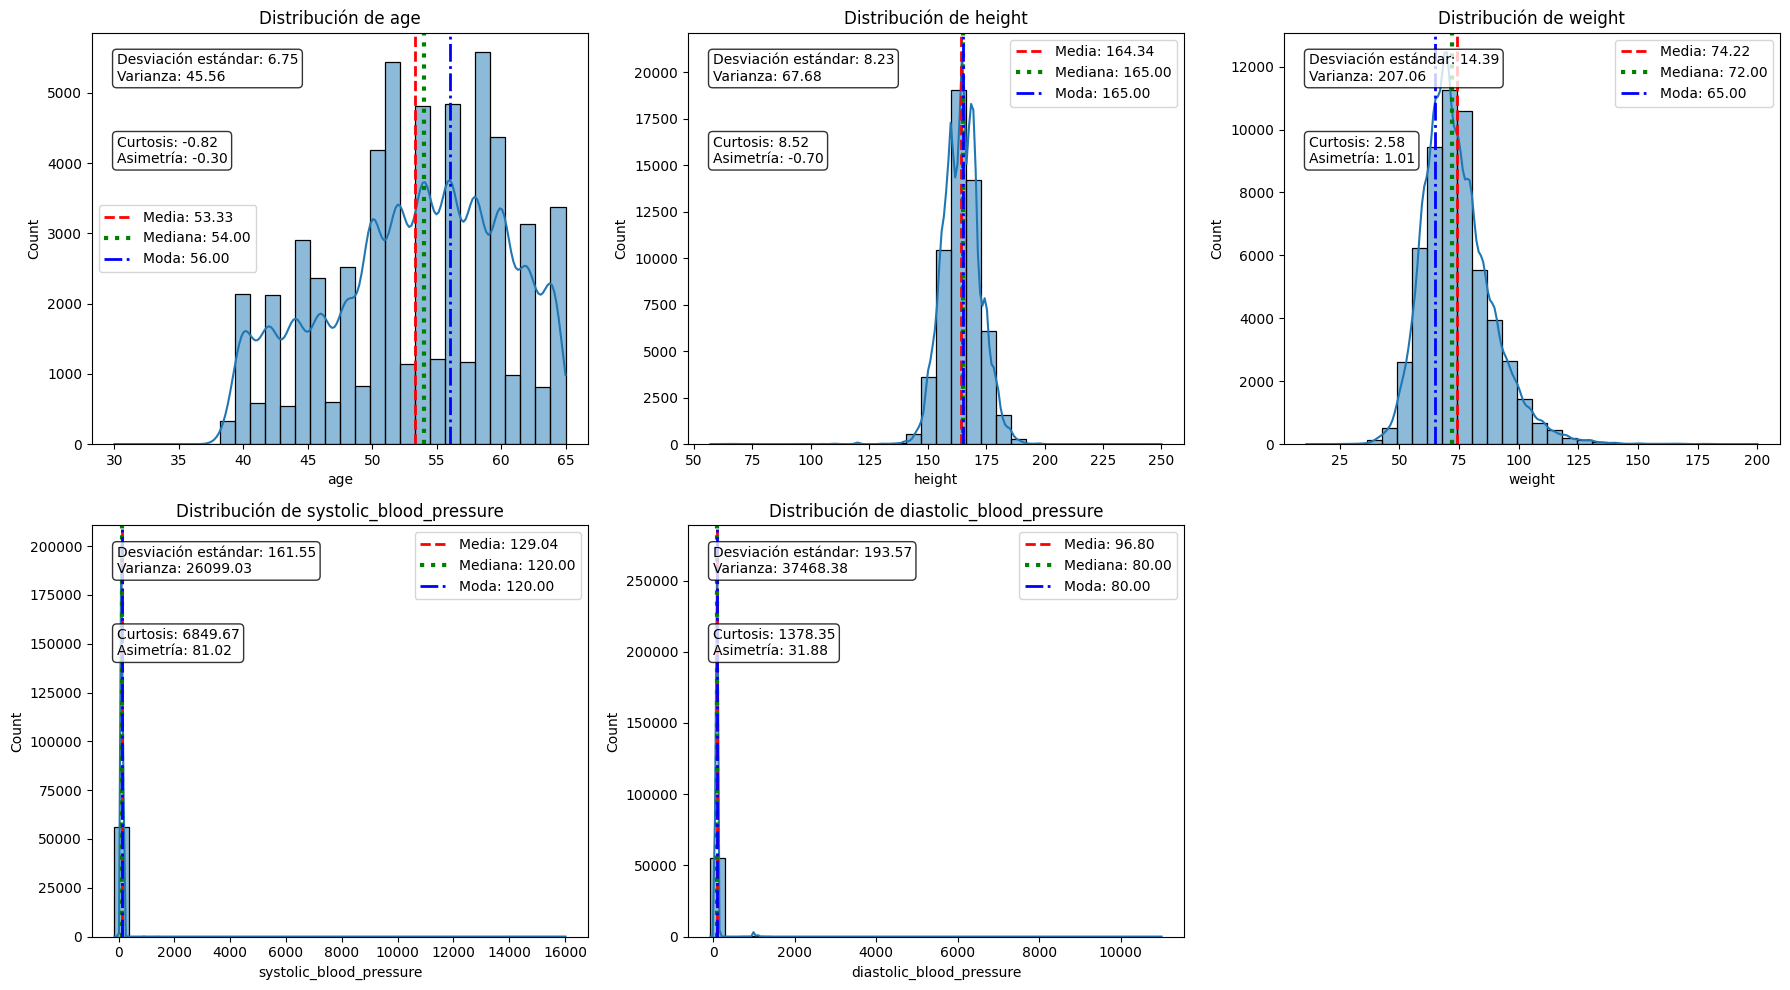

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(num_col):
    ax = axes[i // 3, i % 3]
    sns.histplot(numerical[col], bins=30, kde=True, ax=ax)

    ax.axvline(mean_num[col], color='red', linestyle='--', linewidth=2, label=f'Media: {mean_num[col]:.2f}')
    ax.axvline(median_num[col], color='green', linestyle=':', linewidth=3, label=f'Mediana: {median_num[col]:.2f}')
    ax.axvline(mode_num[col], color='blue', linestyle='-.', linewidth=2, label=f'Moda: {mode_num[col]:.2f}')
    # poner en la legenda, la desviacion estandar y la varianza (pero no una recta)
    ax.text(0.05, 0.95, f'Desviación estándar: {std_num[col]:.2f}\nVarianza: {var_num[col]:.2f}', transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.text(0.05, 0.75, f'Curtosis: {kurtosis_num[col]:.2f}\nAsimetría: {skewness_num[col]:.2f}', transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_title(f"Distribución de {col}")
    ax.legend()

fig.delaxes(axes[1, 2])  # Eliminar el subplot vacío
plt.tight_layout()
plt.show()

<div style="text-align: center;">
    <h3>Interpretación</h3>
</div>

**Age**: Se encuentra gran cantidad de muestras cerca de los 54 años, baja cantidad de outliers y sigue casi una distribución normal.

**Height**: Una acumulación alrededor de los 165cm (1.65 m), su media puede ser representativa y puede presentar una cantidad pequeña de outliers.

**Estas dos** tienen una distribución más facil de interpretar, a la vista no parece tener una gran cantidad de outliers, pero se logran visualizar datos peculiarmente altos o bajos.

**Weight**: Asimetría a la derecha, pocos outliers pero aun asi hay presencia de datos con medidas fuera de lo común.

**Systolic_blood_pressure**: La presión arterial sistólica mide la fuerza de la sangre cuando el corazón se contrae, se encuentra en el rango $$ 90 \lessapprox  \text{Systolic Blood Pressure} \lessapprox  180$$ Pero se visualizan datos cerca de las 16.000 unidades, es por esto que se ve esta gran asimetría a la derecha, se deben tratar estos datos. La media, mediana y moda están cerca de los 120 unidades, esto es una presion arterial sistólica elevada, pero considerando la magnitud de los outliers, se debe tener en cuenta que estas medidas de tendencia central se están "halando" hacia datos mas altos, asi que luego de la limpieza se puede encontrar una media, median y moda distintas.

**Diastolic_blood_pressure**: La presión arterial diastólica es la fuerza que ejerce la sangre contra las paredes de las arterias cuando el corazón descansa entre latidos. esta se encuentra en el rango $$60 \lessapprox \text{Diastolic Blood Pressure} \lessapprox 120$$En el gráfico se observan datos muy superiores a este rango, cerca superando medidas de 10.000 unidades, el análisis es similar a **Systolic_blood_pressure**, también es necesario hacer una limpieza de estos datos.

Veamos estos outliers

$$LI = Q_1-1.5 \cdot IQR$$
$$LS = Q_3+1.5 \cdot IQR$$

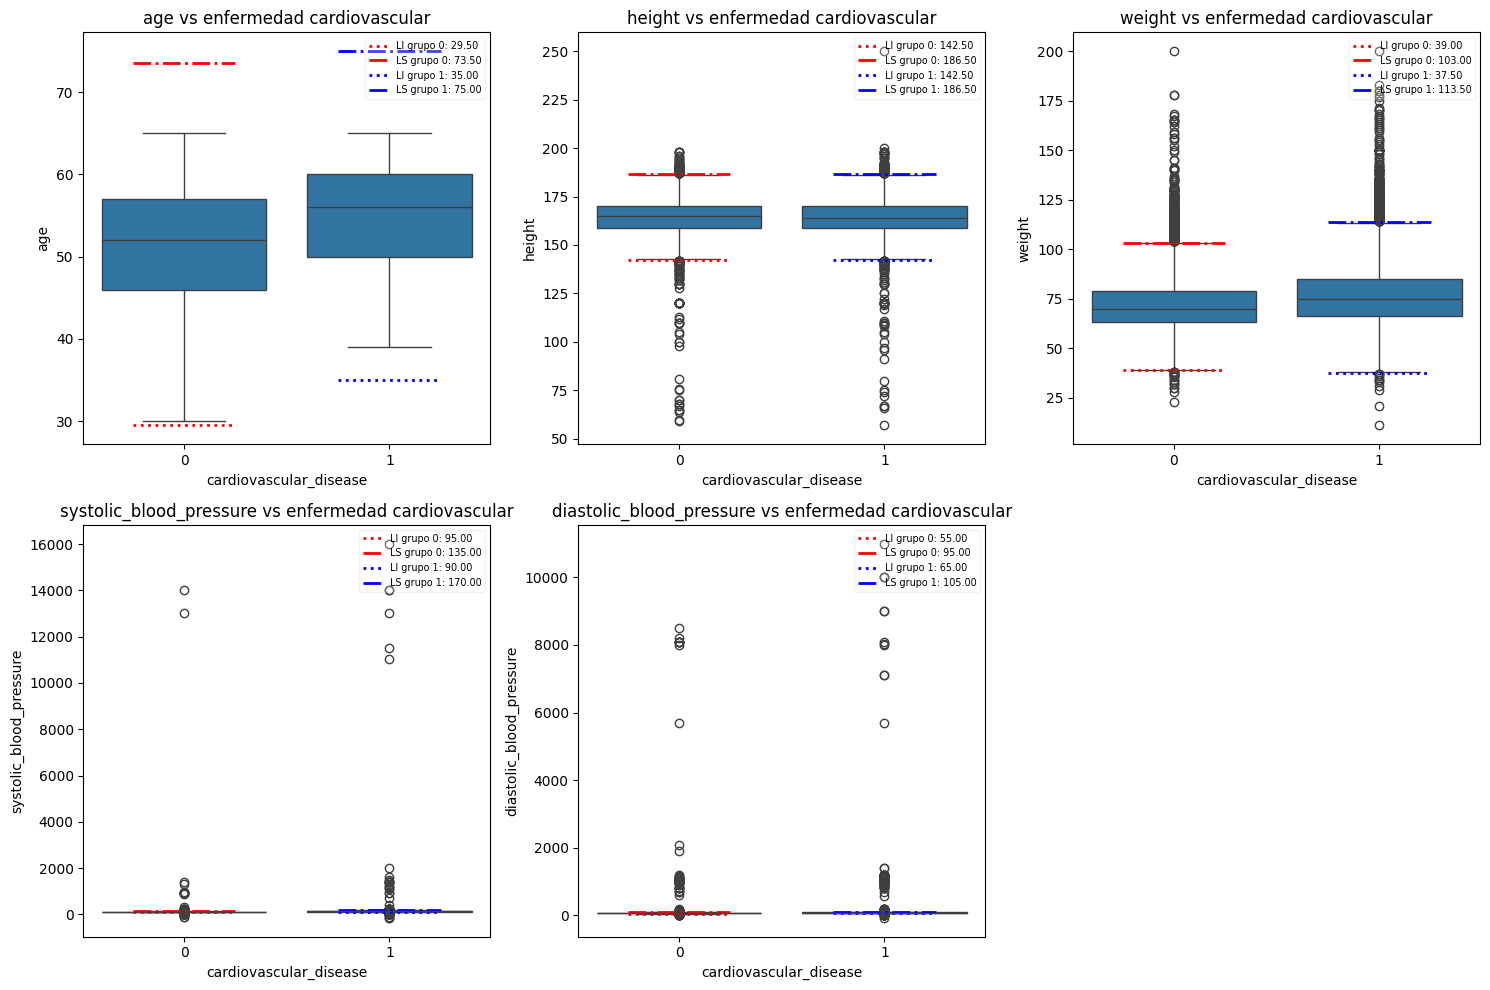

In [52]:
# boxplots para comparar la distribución de cardiovascular_disease con variables numéricas
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(numerical.columns):
    ax = axes[i // 3, i % 3]
    sns.boxplot(x=categorical["cardiovascular_disease"], y=col, data=numerical, ax=ax)

    # medias por grupo
    group_0 = numerical.loc[categorical["cardiovascular_disease"] == 0, col]
    group_1 = numerical.loc[categorical["cardiovascular_disease"] == 1, col]
    mean_0 = group_0.mean()
    mean_1 = group_1.mean()

    # límites de outliers por IQR: Q1 - 1.5*IQR y Q3 + 1.5*IQR
    q1_0, q3_0 = group_0.quantile(0.25), group_0.quantile(0.75)
    iqr_0 = q3_0 - q1_0
    lower_0 = q1_0 - 1.5 * iqr_0
    upper_0 = q3_0 + 1.5 * iqr_0

    q1_1, q3_1 = group_1.quantile(0.25), group_1.quantile(0.75)
    iqr_1 = q3_1 - q1_1
    lower_1 = q1_1 - 1.5 * iqr_1
    upper_1 = q3_1 + 1.5 * iqr_1

    # líneas de límites IQR por grupo (solo sobre el ancho de cada caja)
    ax.hlines(lower_0, -0.25, 0.25, colors='red', linestyles=':', linewidth=2, label=f'LI grupo 0: {lower_0:.2f}')
    ax.hlines(upper_0, -0.25, 0.25, colors='red', linestyles='-.', linewidth=2, label=f'LS grupo 0: {upper_0:.2f}')
    ax.hlines(lower_1, 0.75, 1.25, colors='blue', linestyles=':', linewidth=2, label=f'LI grupo 1: {lower_1:.2f}')
    ax.hlines(upper_1, 0.75, 1.25, colors='blue', linestyles='-.', linewidth=2, label=f'LS grupo 1: {upper_1:.2f}')

    ax.set_title(f"{col} vs enfermedad cardiovascular")
    ax.legend(loc='upper right', fontsize='x-small', framealpha=0.25)

# borrar el subplot vacío
fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

Que en las variables de estatura y edad de presenten datos muy altos o bajos, no signfica que no sean realistas, por lo que basandonos en el gráfico anterior y la realidad, decidiremos eliminar ciertas muestras.

Se presentan muestras de personas que miden menos de 1.40 metros, considerando que la edad minima en este dataset es de 30 años de edad, no se toman en cuenta niños, por lo que los datos con menos de esta estatura serán eliminados. También se eliminarán muestras mayores a 2.30 metros, pues son datos demasiados altos, aquellos que están cerca de esta medida no son poco realistas, existen casos de personas con esta altura.

In [53]:
#eliminar las muestras que tengan una estatura menores a 140cm y mayores a 230cm
data_train_filtered = data_train[data_train["height"] >= 140]
data_train_filtered = data_train_filtered[data_train_filtered["height"] <= 230]
data_train_filtered.describe()

,age,gender,height,weight,systolic_blood_pressure,diastolic_blood_pressure,cholesterol,glucose,smoke,alcohol_intake,physical_activity,bmi,cardiovascular_disease
count,55872.000000,55872.000000,55872.000000,55872.000000,55872.000000,55872.000000,55872.000000,55872.000000,55872.000000,55872.000000,55872.000000,55872.0,55872.000000
mean,53.335195,1.349227,164.456114,74.214968,129.051009,96.820500,1.367000,1.226750,0.087897,0.053050,0.805072,1.990317,0.499803
std,6.748645,0.476730,7.797210,14.334860,161.732922,193.748855,0.680117,0.572379,0.283148,0.224135,0.396149,1.031339,0.500004
min,30.000000,1.000000,140.000000,11.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.0,0.000000
50%,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,2.0,0.000000
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,3.0,1.000000
max,65.000000,2.000000,200.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,5.0,1.000000


In [54]:
data_train_filtered.info()

<class 'pandas.DataFrame'>
Index: 55872 entries, 58394 to 33894
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       55872 non-null  int64  
 1   gender                    55872 non-null  int64  
 2   height                    55872 non-null  int64  
 3   weight                    55872 non-null  float64
 4   systolic_blood_pressure   55872 non-null  int64  
 5   diastolic_blood_pressure  55872 non-null  int64  
 6   cholesterol               55872 non-null  int64  
 7   glucose                   55872 non-null  int64  
 8   smoke                     55872 non-null  int64  
 9   alcohol_intake            55872 non-null  int64  
 10  physical_activity         55872 non-null  int64  
 11  bmi                       55872 non-null  Int64  
 12  cardiovascular_disease    55872 non-null  int64  
dtypes: Int64(1), float64(1), int64(11)
memory usage: 6.0 MB


Del grafico anterior, teniendo en cuenta que el minimo de estatura es 140cm, se descartarán muestras que con un peso menor a 40kg (aproximadamente el LI del gráfico). Adicional a esto, medicamente se considera que la presión arterial sistólica menor a 50 mmHg y superior a 250 mmHg es incompatible con la vida, para el caso de la presión arterial diastólica, aquellos valores inferiores a 30 mmHg y superiores a 200 mmHg se considera una muerte inminente.

A pesar de que en la gráfica se tengan LI y LS que no llegan a estos umbrales, no dejan de ser realistas, por lo que se toma la desición de eliminar los datos anteriormente mencionados.

In [55]:
# eliminar datos que el peso sea menor a 40 kg, systolic_blood_pressure sean menores a 50 y superiores a 250, diastolic_blood_pressure menores a 30 y superiores a 200
data_train_filtered = data_train_filtered[data_train_filtered["weight"] >= 40]
data_train_filtered = data_train_filtered[data_train_filtered["systolic_blood_pressure"] >= 50]
data_train_filtered = data_train_filtered[data_train_filtered["systolic_blood_pressure"] <= 250]
data_train_filtered = data_train_filtered[data_train_filtered["diastolic_blood_pressure"] >= 30]
data_train_filtered = data_train_filtered[data_train_filtered["diastolic_blood_pressure"] <= 200]
data_train_filtered.info()

<class 'pandas.DataFrame'>
Index: 54865 entries, 58394 to 33894
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       54865 non-null  int64  
 1   gender                    54865 non-null  int64  
 2   height                    54865 non-null  int64  
 3   weight                    54865 non-null  float64
 4   systolic_blood_pressure   54865 non-null  int64  
 5   diastolic_blood_pressure  54865 non-null  int64  
 6   cholesterol               54865 non-null  int64  
 7   glucose                   54865 non-null  int64  
 8   smoke                     54865 non-null  int64  
 9   alcohol_intake            54865 non-null  int64  
 10  physical_activity         54865 non-null  int64  
 11  bmi                       54865 non-null  Int64  
 12  cardiovascular_disease    54865 non-null  int64  
dtypes: Int64(1), float64(1), int64(11)
memory usage: 5.9 MB


In [56]:
data_col, num_col, mean_num, median_num, mode_num, std_num, var_num, mode_cat, kurtosis_num, skewness_num = calculate_metrics(data_train_filtered)
categorical, nominal, ordinal, binary, numerical = calculate_sets(data_train_filtered)

Por ultimo, una revision de como cambió la distribución de los datos luego de esta limpieza.

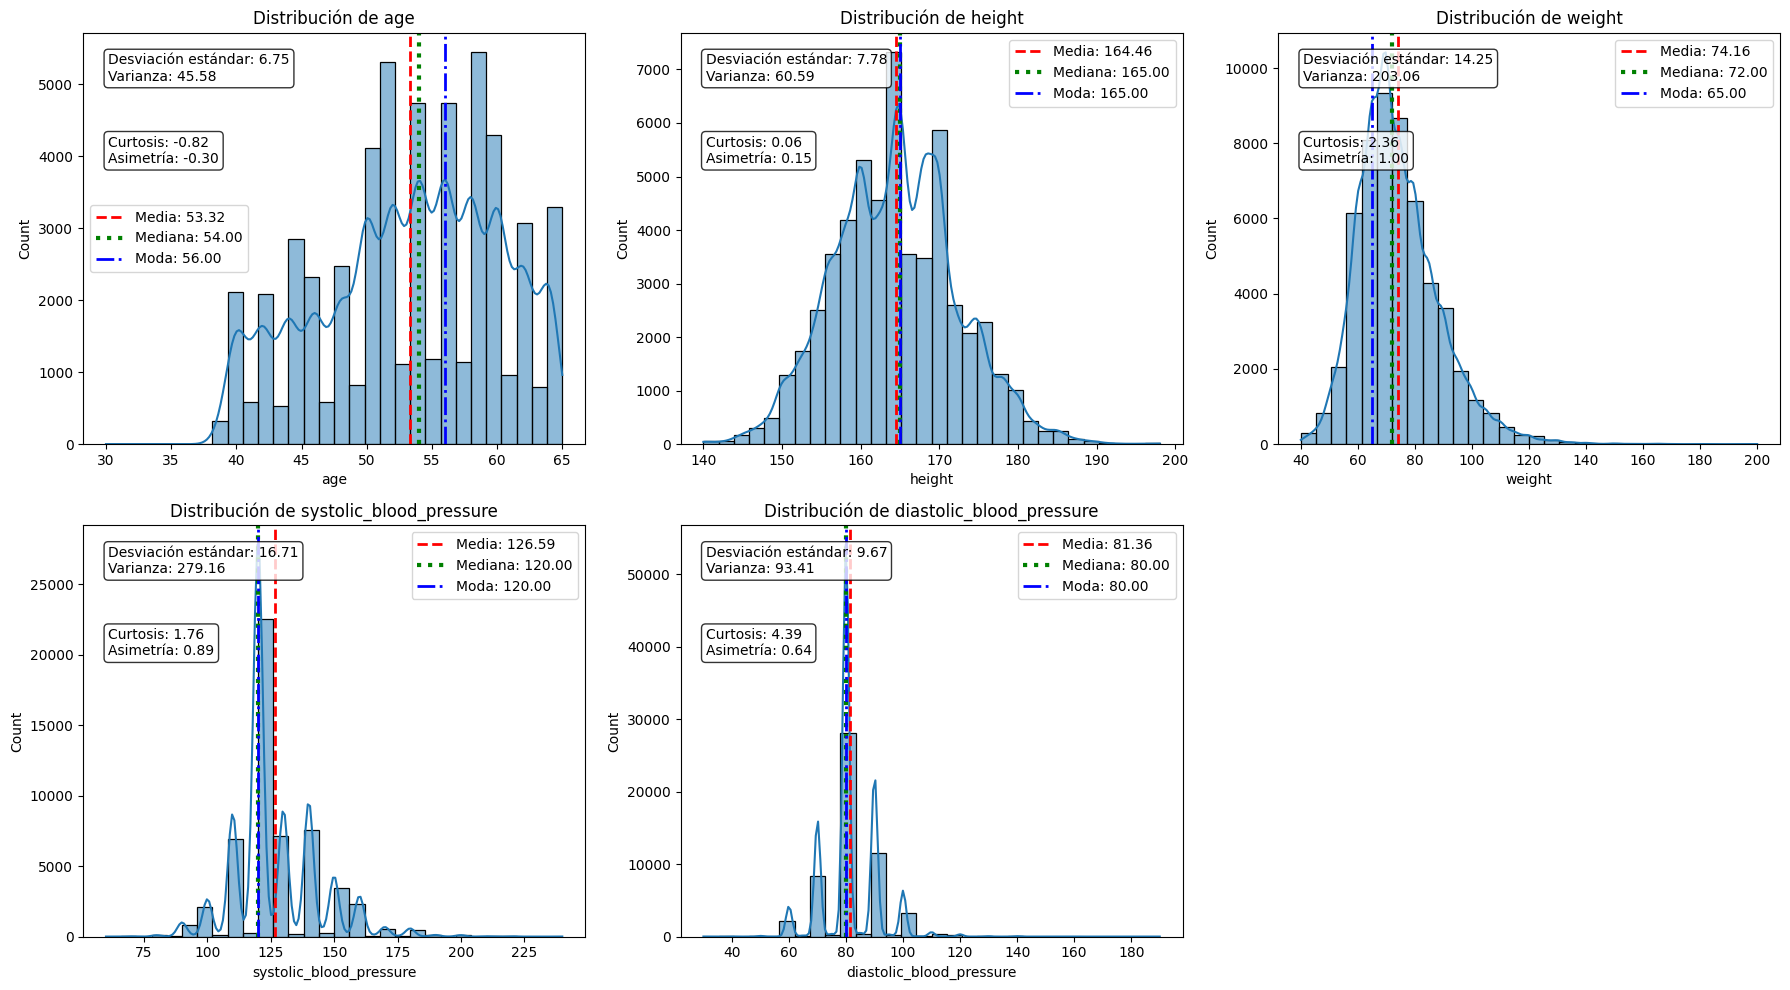

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(num_col):
    ax = axes[i // 3, i % 3]
    sns.histplot(numerical[col], bins=30, kde=True, ax=ax)

    ax.axvline(mean_num[col], color='red', linestyle='--', linewidth=2, label=f'Media: {mean_num[col]:.2f}')
    ax.axvline(median_num[col], color='green', linestyle=':', linewidth=3, label=f'Mediana: {median_num[col]:.2f}')
    ax.axvline(mode_num[col], color='blue', linestyle='-.', linewidth=2, label=f'Moda: {mode_num[col]:.2f}')
    # poner en la legenda, la desviacion estandar y la varianza (pero no una recta)
    ax.text(0.05, 0.95, f'Desviación estándar: {std_num[col]:.2f}\nVarianza: {var_num[col]:.2f}', transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.text(0.05, 0.75, f'Curtosis: {kurtosis_num[col]:.2f}\nAsimetría: {skewness_num[col]:.2f}', transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_title(f"Distribución de {col}")
    ax.legend()

fig.delaxes(axes[1, 2])  # Eliminar el subplot vacío
plt.tight_layout()
plt.show()

La distribución de los datos no ha cambiado mucho

Ahora continuamos con el análisis de los datos categoricos

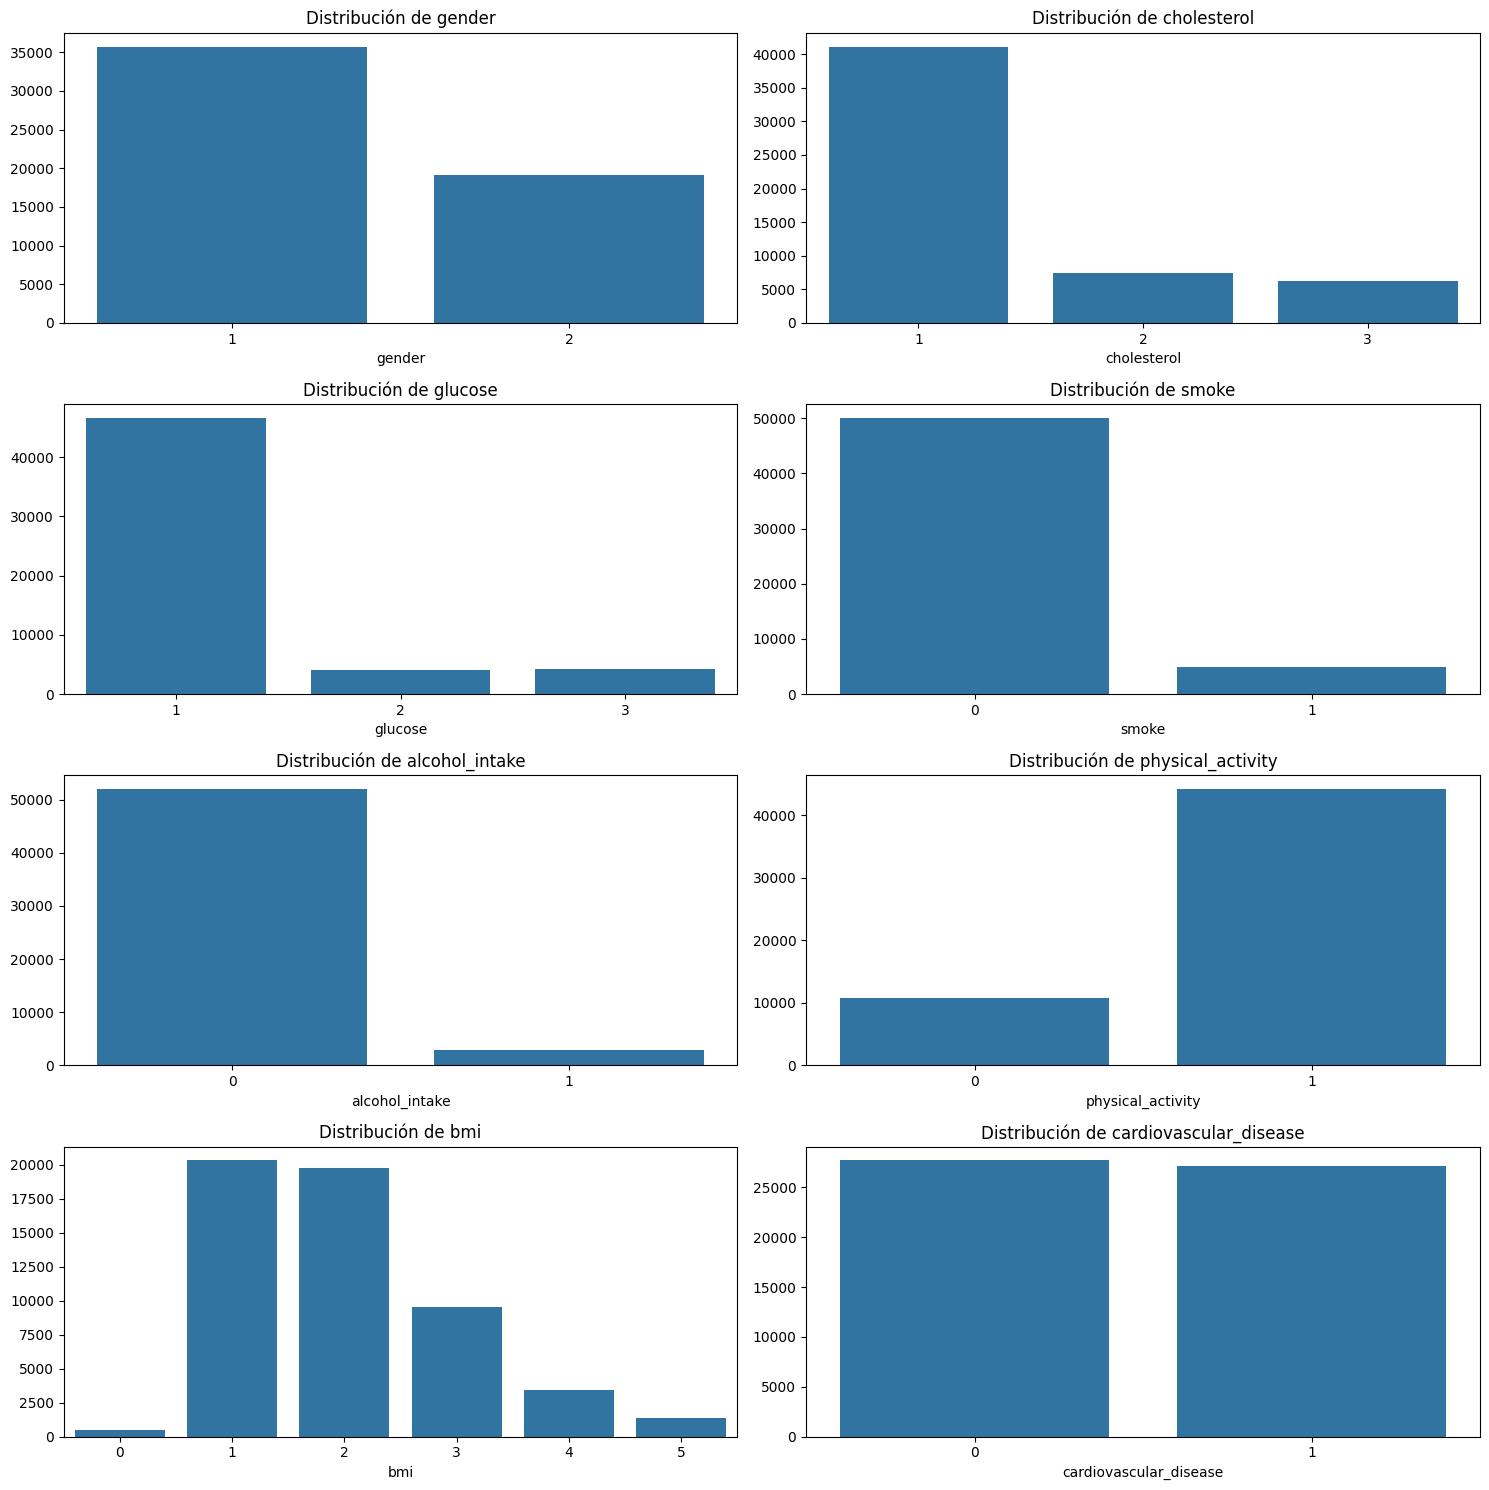

In [58]:
fig, axes = plt.subplots(4, 2, figsize=(15, 15))
for i, col in enumerate(cat_col):
    # grafico con sus modas
    sns.barplot(x = categorical[col].value_counts().index, y = categorical[col].value_counts().values,ax=axes[i//2, i%2])


    axes[i//2, i%2].set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()

In [59]:
categorical["cardiovascular_disease"].value_counts()

cardiovascular_disease
0    27701
1    27164
Name: count, dtype: int64

De este grafico no podemos interpretar mucho, pues practicamente todas las variables categoricas están desbalanceadas, para esto observaremos las crosstab con relación a cardiovascular_disease

In [60]:
target = ((categorical.columns).to_list())[-1]
for col in ((categorical.columns).to_list())[:-1]:
    print()
    print(f"Relación entre {col} y {target}")
    print()

    table = pd.crosstab(data_train_filtered[col],data_train_filtered[target],normalize="index") * 100

    print(table.round(2))


Relación entre gender y cardiovascular_disease

cardiovascular_disease      0      1
gender                              
1                       50.63  49.37
2                       50.23  49.77

Relación entre cholesterol y cardiovascular_disease

cardiovascular_disease      0      1
cholesterol                         
1                       56.42  43.58
2                       40.47  59.53
3                       23.54  76.46

Relación entre glucose y cardiovascular_disease

cardiovascular_disease      0      1
glucose                             
1                       52.47  47.53
2                       40.79  59.21
3                       37.81  62.19

Relación entre smoke y cardiovascular_disease

cardiovascular_disease      0      1
smoke                               
0                       50.19  49.81
1                       53.60  46.40

Relación entre alcohol_intake y cardiovascular_disease

cardiovascular_disease      0      1
alcohol_intake                      
0 

Encontramos que el **genero** parece no tener gran impacto por si solo, practicamente el 50% de las mujeres y de los hombres tiene enfermedad **cardiovascular**, mientras que la otra mitad no.

Para la **glucosa** y el **colesterol**, entre mas cerca a la medida **"normal"** esté un paciente, menos probable es que sufra de problemas cardiovasculares, mientras que entre más suba de este umbral, más es la probabilidad de sufrir de estas enfermedades.

**Fumar** y **consumir alchool** no tiene gran diferencia en el resultado, se logra ver que independientemente de si se hace o no, sigue siendo un poco más probable que no se sufra de enfermedad cardiovascular, aunque esta tendencia sea muy pequeña.

En cuanto a la **actividad fisica**, aquellos pacientes que más se ejercitan o realizan esfuerzo fisico tienen menos probabilidades de sufrir problemas cardiovasculares.

Para el **bmi**, que no se debe olvidar, es la variable ordinal creada que habla de el indice de masa corporal, se observa que entre más sobrepeso tenga el paciente, más probabilidad tiene de sufrir estos problemas cardiovasculares.

Se logra apreciar un **desbalance** en caracteristicas como **alcohol_intake**, **smoke**, **glucose**, **cholesterol** y **physycal_activity**

### Observemos la relacion entre las variables numéricas

In [61]:


target = ((categorical.columns).to_list())[-1]

for col in (numerical.columns).to_list():
    print()
    print(f"Distribución de {col} según {target}")
    print()

    summary = data_train_filtered.groupby(target)[col].describe()

    print(summary.round(2))


Distribución de age según cardiovascular_disease

                          count   mean   std   min   25%   50%   75%   max
cardiovascular_disease                                                    
0                       27701.0  51.70  6.76  30.0  46.0  52.0  57.0  65.0
1                       27164.0  54.97  6.33  39.0  50.0  56.0  60.0  65.0

Distribución de height según cardiovascular_disease

                          count    mean   std    min    25%    50%    75%  \
cardiovascular_disease                                                      
0                       27701.0  164.59  7.67  140.0  159.0  165.0  170.0   
1                       27164.0  164.33  7.89  140.0  159.0  164.0  170.0   

                          max  
cardiovascular_disease         
0                       198.0  
1                       198.0  

Distribución de weight según cardiovascular_disease

                          count   mean    std   min   25%   50%   75%    max
cardiovascular_disease     

En **promedio**, quienes más suelen tener enfermedades cardiovasculares son personas que tiene alrededor de **54 años de edad**, **1.64 metros** de estatura, un peso de **76 kg**, una presión articular sistólica de aproximadamente ** 133 mmHg** (Hipertensión grado 1), presión arterial diastolica de **84 mmHg** (Hipertensión grado 1)

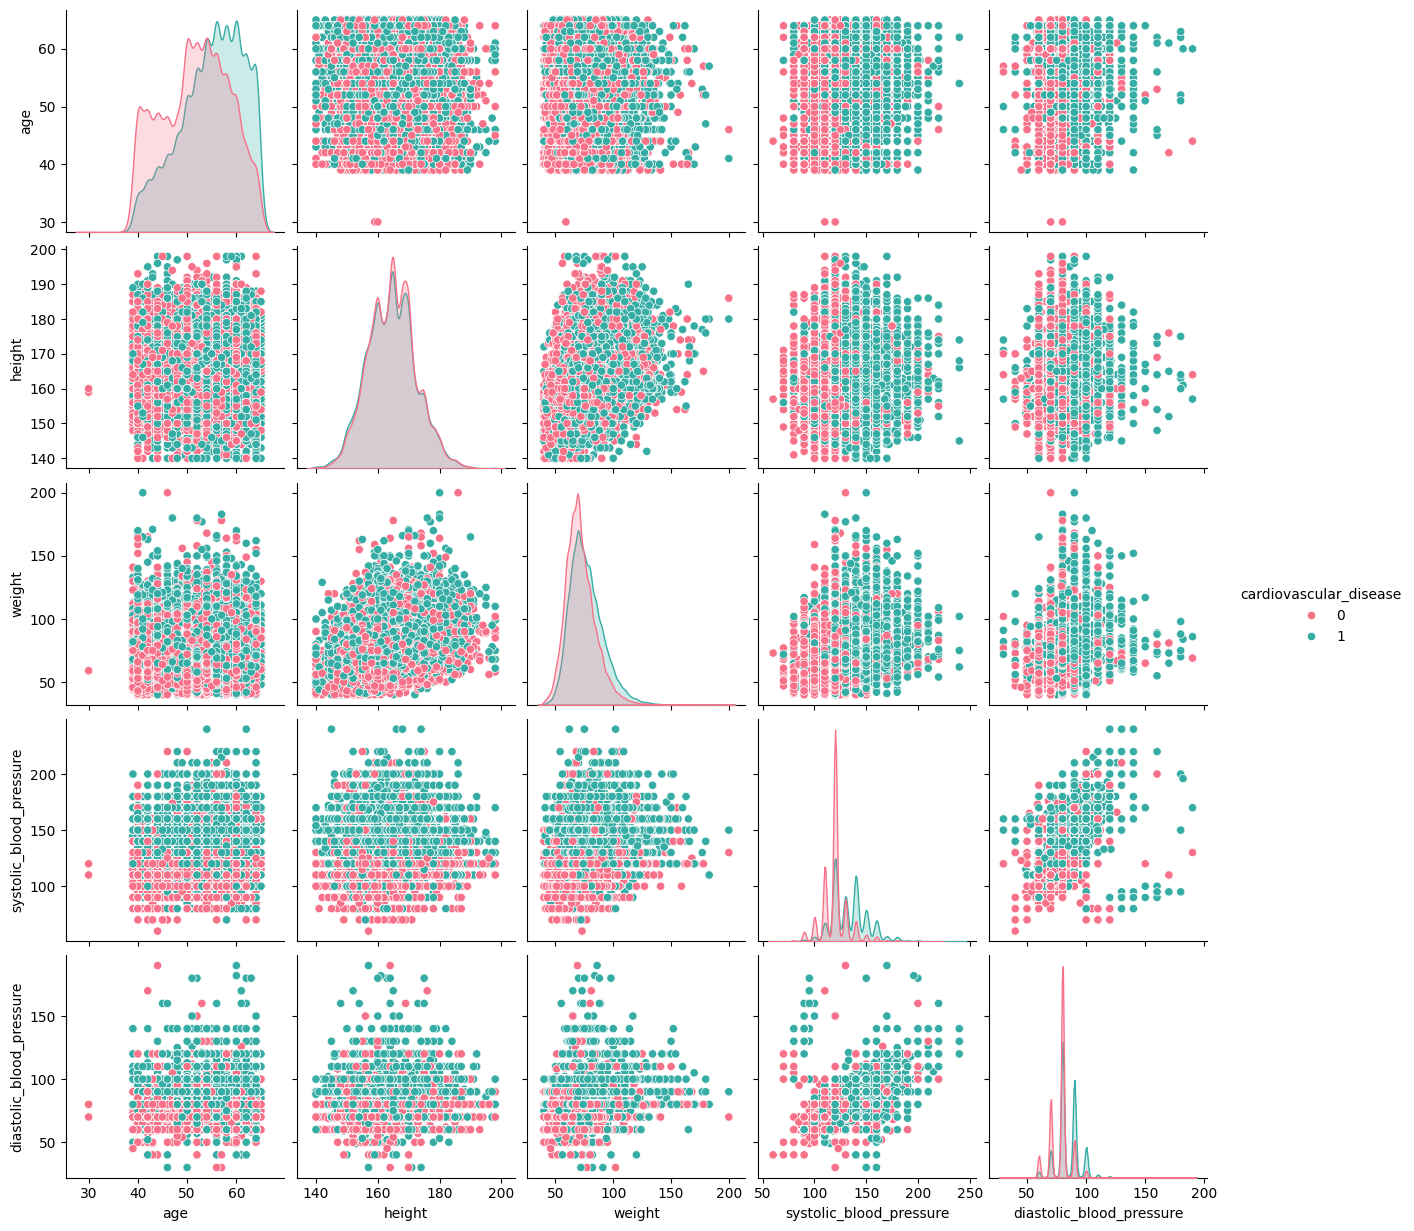

In [62]:
sns.pairplot(numerical.join(categorical["cardiovascular_disease"]), hue="cardiovascular_disease", diag_kind="kde", palette='husl')
plt.show()

En este **pairplot**, puede ser un poco dificil de interpretar, más al querer encontrar algún tipo de patron, el más visible es el que se ve entre **diastolic_blood_pressure** y **systolic_blood_pressure**, que se logra ver una relación **directa** y casi lineal. Para mayor presición se hará una matriz de correlación.

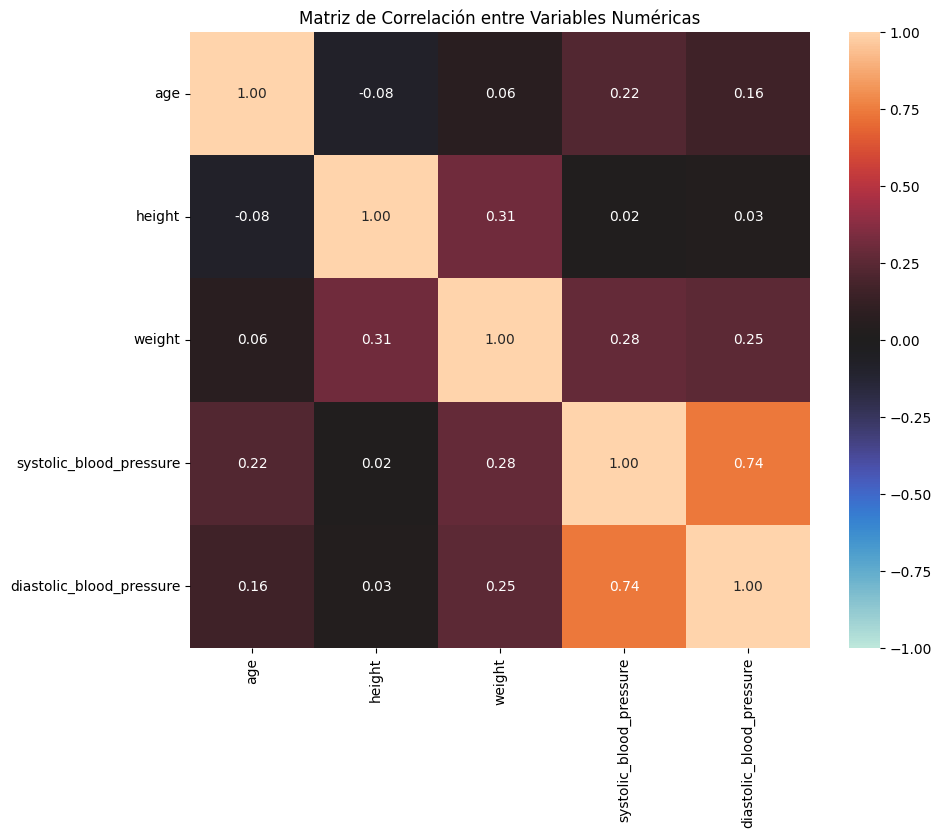

In [63]:
# matriz de correlación para las variables numéricas
 
plt.figure(figsize=(10, 8))
sns.heatmap((numerical).corr(method='spearman'), annot=True, fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.show()

Una **Correlación** notoria es la mencionada anteriormente, entre **diastolic_blood_pressure** y **systolic_blood_pressure**, la cual si es directa y fuerte pero, siendo la prueba de **Spearman** la relación no parece ser tan consistente como para ser lineal.

Otras **correlaciones** que se observan son **Weight** y **Height**, que aunque no sea tan fuerte, puede ser fundamental en el modelaje, y finalmente **Weight** con **Systolic_blood_pressure** y **Weight** con **Diastolic_blood_pressure**, que aunque estas ultimas dos son las menos fuerte, pueden tener una relación fundamental.

### Asociación de las variables categoricas

## Prueba chi-cuadrado de independencia

Se aplicó la prueba chi-cuadrado de independencia para evaluar si existe evidencia estadística de asociación entre cada variable categórica y la variable objetivo `cardiovascular_disease`.

La prueba contrasta las siguientes hipótesis:

$$H_0: X \perp Y$$

$$H_a: X \not\perp Y$$

Donde:

- $H_0$: la variable categórica $X$ y la variable objetivo $Y$ son independientes.
- $H_a$: la variable categórica $X$ y la variable objetivo $Y$ no son independientes, es decir, existe asociación estadística entre ambas.

Se utiliza un nivel de significancia:

$$\alpha = 0.05$$

Criterio de decisión:

- Si \(p < 0.05\), se rechaza $H_0$
  Existe evidencia estadística de asociación entre la variable categórica y la enfermedad cardiovascular.

- Si \(p $\geq$ 0.05\), no se rechaza $H_0$
  No existe evidencia estadística suficiente para afirmar asociación entre la variable categórica y la enfermedad cardiovascular.

In [64]:
alpha = 0.05
target = "cardiovascular_disease"

categorical_cols = [col for col in categorical.columns if col != target]

for col in categorical_cols:
    contingency_table = pd.crosstab(categorical[col],categorical[target])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    decision = ("Se rechaza H0: existe evidencia de asociación" if p_value < alpha else "No se rechaza H0: no hay evidencia suficiente de asociación")

    print(f"{col}:")
    print(f"\tChi2: {chi2:.2f}")
    print(f"\tp-value: {p_value:.4f}")
    print(f"\tGrados de libertad: {dof}")
    print(f"\tDecisión: {decision}")
    print()

gender:
	Chi2: 0.78
	p-value: 0.3785
	Grados de libertad: 1
	Decisión: No se rechaza H0: no hay evidencia suficiente de asociación

cholesterol:
	Chi2: 2705.65
	p-value: 0.0000
	Grados de libertad: 2
	Decisión: Se rechaza H0: existe evidencia de asociación

glucose:
	Chi2: 494.92
	p-value: 0.0000
	Grados de libertad: 2
	Decisión: Se rechaza H0: existe evidencia de asociación

smoke:
	Chi2: 20.31
	p-value: 0.0000
	Grados de libertad: 1
	Decisión: Se rechaza H0: existe evidencia de asociación

alcohol_intake:
	Chi2: 4.29
	p-value: 0.0383
	Grados de libertad: 1
	Decisión: Se rechaza H0: existe evidencia de asociación

physical_activity:
	Chi2: 62.63
	p-value: 0.0000
	Grados de libertad: 1
	Decisión: Se rechaza H0: existe evidencia de asociación

bmi:
	Chi2: 2009.21
	p-value: 0.0000
	Grados de libertad: 5
	Decisión: Se rechaza H0: existe evidencia de asociación



La unica variable que no muestra asociación con los problemas cardiovasculares es el genero, podria no ser necesaria para el trabajo de predicción.

**Phi Coefficient** y **V de Cramer**para determinar la magnitud de asociación de las variables binarias y ordinales respectivamente

**Criterios a usar en V de cramer y Phi**

0.00 - 0.10 → asociación muy débil

0.10 - 0.30 → asociación débil

0.30 - 0.50 → asociación moderada

$ \gt $ 0.50 → asociación fuerte

In [65]:
for col in binary.columns:
    if col == target:
        continue

    table = pd.crosstab(binary[col], binary[target])
    chi2, p, dof, expected = chi2_contingency(table)

    n = table.sum().sum()
    phi = np.sqrt(chi2 / n)

    print(f"{col}")
    print(f"Chi2: {chi2:.2f}")
    print(f"p-value: {p:.4f}")
    print(f"Phi: {phi:.4f}")

    if p < alpha:
        print("Decisión: asociada con la variable objetivo")
    else:
        print("Decisión: no hay evidencia suficiente de asociación")

    print()

gender
Chi2: 0.78
p-value: 0.3785
Phi: 0.0038
Decisión: no hay evidencia suficiente de asociación

smoke
Chi2: 20.31
p-value: 0.0000
Phi: 0.0192
Decisión: asociada con la variable objetivo

alcohol_intake
Chi2: 4.29
p-value: 0.0383
Phi: 0.0088
Decisión: asociada con la variable objetivo

physical_activity
Chi2: 62.63
p-value: 0.0000
Phi: 0.0338
Decisión: asociada con la variable objetivo



Las variables **alcohol_intake**, **smoke** y **physical_activity** aunque estén asociadas con la variable objetivo, no parecen tener una asociación muy fuerte, siendo **alcohol_intake** la menos asociada y **physical_activity** la que tiene mayor asociación.

In [66]:
for col in ordinal.columns:
    table = pd.crosstab(ordinal[col], categorical[target])
    chi2, p, dof, expected = chi2_contingency(table)

    n = table.sum().sum()
    r, c = table.shape

    cramer_v = np.sqrt(chi2 / (n * min(r - 1, c - 1)))

    print(f"{col}")
    print(f"Chi2: {chi2:.2f}")
    print(f"p-value: {p:.4f}")
    print(f"Cramer V: {cramer_v:.4f}")

    if p < alpha:
        print("Decisión: asociada con la variable objetivo")
    else:
        print("Decisión: no hay evidencia suficiente de asociación")

    print()

cholesterol
Chi2: 2705.65
p-value: 0.0000
Cramer V: 0.2221
Decisión: asociada con la variable objetivo

glucose
Chi2: 494.92
p-value: 0.0000
Cramer V: 0.0950
Decisión: asociada con la variable objetivo

bmi
Chi2: 2009.21
p-value: 0.0000
Cramer V: 0.1914
Decisión: asociada con la variable objetivo



Por parte de las variable ordinales, **glucose** tiene una asociación muy debil, mientras que, **bmi** y **cholesterol** tienen asociación debil, siendo **cholesterol** más **fuerte** que **bmi**.

### Tau de Kendall

$$-1 \leq \tau \leq 1$$

$\tau \gt 0$: asociación positiva: valores altos de X tienden a coincidir con cardio = 1

$\tau \lt 0$: asociación negativa: valores altos de X tienden a coincidir con cardio = 0

$\tau \approx 0$: poca o nula asociación

In [67]:
ordinal_cols = ["cholesterol", "glucose", "bmi"]
target = "cardiovascular_disease"

for col in ordinal_cols:
    tau, p_value = kendalltau(data_train_filtered[col],data_train_filtered[target])

    print(f"{col}")
    print(f"Kendall tau: {tau:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Hay evidencia de asociación")
        match tau:
            case tau if (tau > 0):
                print(f"valores altos de {col} tienden a coincidir con {target} = 1")
            case tau if (tau == 0):
                print(f"no hay asociación entre {col} y {target}")
            case tau if(tau < 0):
                print(f"valores altos de {col} tienden a coincidir con {target} = 0")
    else:
        print("No hay evidencia suficiente de asociación")

    print()

cholesterol
Kendall tau: 0.2091
p-value: 0.0000
Hay evidencia de asociación
valores altos de cholesterol tienden a coincidir con cardiovascular_disease = 1

glucose
Kendall tau: 0.0932
p-value: 0.0000
Hay evidencia de asociación
valores altos de glucose tienden a coincidir con cardiovascular_disease = 1

bmi
Kendall tau: 0.1754
p-value: 0.0000
Hay evidencia de asociación
valores altos de bmi tienden a coincidir con cardiovascular_disease = 1



Vemos que entre más altos los niveles de **colesterol**, de **Indice de masa corporal** y de **glucosa** más probable es sufrir de enfermedades cardiovasculares.

<div style="text-align: center;">
    <h3>Para finalizar</h3>
</div>

Observemos con cuanto porcentaje de datos hemos quedado al final de este analisis y la eliminación de datos.

In [68]:
print("datos iniciales: ", data_train.shape)
print("datos filtrados: ", data_train_filtered.shape)

print("Porcentaje de datos eliminados: ", round(((1 - data_train_filtered.shape[0] / data_train.shape[0]) * 100), 4), "%")

datos iniciales:  (56000, 13)
datos filtrados:  (54865, 13)
Porcentaje de datos eliminados:  2.0268 %


Se han elminado menos de un **3%** de los registros luego de hacer la limpieza.

<div style="text-align: center;">
    <h1>Conclusiones</h1>
</div>

- Se observa utíl la creación de una nueva variable ordinal llamada 'bmi' la cual representa el indice de masa corporal de cada paciente con rangos de entre 0 a 5.
- La variable objetivo está practicamente balanceada, esto facilitará el proceso cuando se deseé realizar la predicción.
- Se hizo limpieza de muestras con una estatura menor a 140cm y mayor a 230cm, peso menor a 40kg, presion arterial sistolica menor a 50 y mayor a 250 y con una presion arterial distolica menor a 30 y mayor a 200.
- La mayoria de variables categoricas muestran una asociación debil, pero aun asi debido a la dimensionalidad del problema, puede ser importante mantenerlas.
- En las variable numericas, las presiones arteriales sistólicas y diastólicas tiene una gran correlación, aun asi, son medidas con umbrales diferentes y con contextos distintos, por esto, se mantendrán en el set de datos.
- Variables consideradas a eliminar serán id y genero, pues esta ultima no parece tener gran peso en este problema.
- Menos de un 3% de las muestras fueron eliminadas, luego de la limpieza
